In [69]:
import os
import random

# Set environment variables FIRST
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import numpy as np
import pandas as pd
import torch
from scipy.optimize import minimize
from datetime import timedelta

# Seed everything
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Optional - might need to disable if operations fail
torch.use_deterministic_algorithms(True)

In [70]:
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
        "quarterly_metrics": {
            "2025 Q2": {"ftp": 269, "max_hr": 183, "rhr": 40},
            "2025 Q1": {"ftp": 282, "max_hr": 193, "rhr": 40},
            "2024 Q4": {"ftp": 292, "max_hr": 191, "rhr": 40},
            "2024 Q3": {"ftp": 306, "max_hr": 189, "rhr": 40},
            "2024 Q2": {"ftp": 294, "max_hr": 188, "rhr": 40},
            "2024 Q1": {"ftp": 298, "max_hr": 192, "rhr": 40},
        }
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all",
        "quarterly_metrics": {
            "2025 Q2": {"ftp": 345, "max_hr": 194, "rhr": None},
            "2025 Q1": {"ftp": 341, "max_hr": 193, "rhr": None},
            "2024 Q4": {"ftp": 308, "max_hr": 194, "rhr": None},
            "2024 Q3": {"ftp": 306, "max_hr": 191, "rhr": None},
            "2024 Q2": {"ftp": 306, "max_hr": 191, "rhr": None},
            "2024 Q1": {"ftp": 306, "max_hr": 191, "rhr": None},
        }
    }
}

In [71]:
def read_hr_data(csv_path):
    """
    Load raw heart rate data from a CSV file with no modifications.

    Args:
        csv_path (str): Path to the CSV file.

    Returns:
        pd.DataFrame: Raw DataFrame exactly as read from the file.
    """
    return pd.read_csv(csv_path)


In [72]:
def process_hr_data(df: pd.DataFrame, athlete_name: str, athletes: dict,
                    window_size: int = 5, long_window: int = 10,
                    seven_zone_model: bool = True) -> pd.DataFrame:
    """
    Processes raw HR CSV data into a feature-rich DataFrame.

    Assumes 'timestamp', 'power', 'heart_rate', and 'Manual_Timestamps' columns are present.
    Cleans NaN/inf at the end so ML models don't see NaNs.
    """
    # Parse and sort timestamps
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)

    # Reindex to fill missing seconds
    expected = pd.date_range(start=df['timestamp'].min(), end=df['timestamp'].max(), freq='1s')
    df = df.set_index('timestamp').reindex(expected).reset_index().rename(columns={'index': 'timestamp'})

    # Compute delta_time from timestamp column
    df['delta_time'] = df['timestamp'].diff().dt.total_seconds()
    # first row will be NaN -> set to 0
    df['delta_time'] = df['delta_time'].fillna(0)

    # Binary manual labels
    df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
    df.loc[0, 'manual_timestamp_numerical'] = 1

    # Get seasonal values or fallback to base
    session_start = df['timestamp'].min()
    quarter = f"{session_start.year} Q{((session_start.month - 1) // 3) + 1}"
    athlete_meta = athletes[athlete_name]
    seasonal = athlete_meta.get("quarterly_metrics", {}).get(quarter, {})

    rest_hr = seasonal.get("rhr", None)
    max_hr = seasonal.get("max_hr", None)
    ftp = seasonal.get("ftp", athlete_meta["ftp"])

    # Rolling averages and derivatives
    df['power_roll_avg'] = df['power'].rolling(window=window_size, center=True, min_periods=1).mean()
    df['hr_roll_avg'] = df['heart_rate'].rolling(window=window_size, center=True, min_periods=1).mean()

    # avoid div by 0 in derivatives
    # make a small eps where delta_time == 0
    eps = 1e-6
    delta = df['delta_time'].replace(0, eps)

    df['hr_derivative'] = df['hr_roll_avg'].diff() / delta
    df['hr_second_derivative'] = df['hr_derivative'].diff() / delta

    roll_avg_long = df['heart_rate'].rolling(window=long_window, center=True, min_periods=1).mean()
    df['hr_derivative_10s'] = roll_avg_long.diff() / delta

    # HR zones
    if rest_hr is not None and max_hr is not None:
        intensity = (df['hr_roll_avg'] - rest_hr) / (max_hr - rest_hr)
        df['hr_zone_hr_reserve'] = pd.cut(
            intensity,
            bins=[-np.inf, 0.5, 0.7, 0.8, 0.9, np.inf],
            labels=[1, 2, 3, 4, 5]
        ).astype('Int64')
    if max_hr is not None:
        df['hr_zone_olympia'] = pd.cut(
            df['hr_roll_avg'],
            bins=[-np.inf, 72, 82, 87, 92, np.inf],
            labels=[1, 2, 3, 4, 5]
        ).astype('Int64')

    # Power zone classification
    if seven_zone_model:
        power_bins = [0, 55, 75, 90, 105, 120, 150, float('inf')]
        power_labels = list(range(1, 8))
    else:
        power_bins = [0, 55, 75, 90, 105, 120, float('inf')]
        power_labels = list(range(1, 7))

    df['Power_Zone'] = pd.cut(df['power_roll_avg'] / ftp * 100, bins=power_bins, labels=power_labels)
    df['Power_Zone'] = df['Power_Zone'].cat.codes.replace(-1, np.nan)
    df["Power_Zone_Label"] = df["Power_Zone"].map({i: f"Zone{i+1}" for i in range(7)})

    # Assign gt_zone_type using Power_Zone_Label
    df["gt_zone_type"] = "Unclassified"
    gt_times = df[df["manual_timestamp_numerical"] == 1]['timestamp'].to_list()

    if gt_times:
        for i in range(len(gt_times)):
            start = gt_times[i]
            end = gt_times[i + 1] if i + 1 < len(gt_times) else df['timestamp'].iloc[-1]
            mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
            zone_subset = df.loc[mask, "Power_Zone_Label"].dropna()
            dominant_zone = zone_subset.mode().iloc[0] if not zone_subset.empty else "Unclassified"
            df.loc[mask, "gt_zone_type"] = dominant_zone

    # 🔥 FINAL CLEANUP HERE 🔥
    # replace infs → NaN → ffill/bfill → 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = (
        df[numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .bfill()
        .fillna(0.0)
    )

    return df


In [73]:
def process_hr_features_for_all_sessions(athletes: dict) -> dict:
    """
    Processes HR features for all athlete sessions using separated reading and processing steps.

    Args:
        athletes (dict): Dictionary containing athlete metadata.

    Returns:
        dict: A dictionary mapping (athlete, session_name) -> processed DataFrame
    """
    session_data = {}

    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]

        if allowed == "all":
            allowed_csvs = {f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")}
        else:
            allowed_csvs = {f.replace(".fit", "_with_manual_labels.csv") for f in allowed}

        for filename in allowed_csvs:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                print(f"⚠️ Skipping missing file: {file_path}")
                continue

            try:
                raw_df = read_hr_data(file_path)
                processed_df = process_hr_data(raw_df, athlete_name=athlete, athletes=athletes)
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = processed_df
            except Exception as e:
                print(f"❌ Error in {file_path}: {e}")

    return session_data


In [74]:
hr_session_data = process_hr_features_for_all_sessions(athletes)

In [75]:
# your fixed test sessions
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

# hr_session_data already exists from your processing step
test_session_dict = {k: v for k, v in hr_session_data.items() if k in test_sessions}
train_session_dict = {k: v for k, v in hr_session_data.items() if k not in test_sessions}


In [76]:
import numpy as np
import pandas as pd

def widen_change_points(y: np.ndarray, past: int = 3, future: int = 7) -> np.ndarray:
    """
    y: 1D numpy array of 0/1 (length T)
    past/future: how many time steps to also mark as 1 around each change point
                  (will clip to array bounds)
    """
    y = y.copy()
    idxs = np.where(y == 1)[0]
    T = len(y)
    for i in idxs:
        start = max(0, i - past)
        end = min(T, i + future + 1)  # +1 for slicing
        y[start:end] = 1
    return y


In [77]:
FEATURE_COLS = [
    "heart_rate",
    "hr_roll_avg",
    "hr_derivative",
    "hr_second_derivative",
    "hr_derivative_10s",
    "delta_time",
    "hr_zone_olympia",
    "hr_zone_hr_reserve"
]

TARGET_COL = "manual_timestamp_numerical"

def sessions_to_arrays(hr_session_data: dict, past: int = 3, future: int = 7):
    """
    Turns your dict into a list of (X, y) sequences.
    X: (T, F)
    y: (T,)
    past, future: how many time steps around each 1 to widen as positive
    """
    sequences = []
    for (athlete, session), df in hr_session_data.items():
        # drop rows where we somehow lost HR
        df_feat = df[FEATURE_COLS].astype(float)
        y = df[TARGET_COL].astype(int).to_numpy()

        # widen labels
        y = widen_change_points(y, past=past, future=future)

        X = df_feat.to_numpy()  # (T, F)
        sequences.append({
            "athlete": athlete,
            "session": session,
            "X": X,
            "y": y,
        })
    return sequences



In [78]:
train_sequences = sessions_to_arrays(train_session_dict)

In [79]:
import random

class WindowedHRDataset:
    def __init__(self, sequences, window_size=128, pos_radius=128, neg_ratio=2.0):
        """
        sequences: list of dicts from sessions_to_arrays
        window_size: total length of each sample
        pos_radius: half-window around a positive index
        neg_ratio: how many negative samples per positive sample
        """
        self.samples = []
        half = window_size // 2

        for seq in sequences:
            X = seq["X"]
            y = seq["y"]
            T = len(y)

            # 1) positive-centered windows
            pos_idxs = np.where(y == 1)[0]
            for idx in pos_idxs:
                start = idx - half
                end = idx + half
                # pad if needed
                pad_left = 0
                pad_right = 0
                if start < 0:
                    pad_left = -start
                    start = 0
                if end > T:
                    pad_right = end - T
                    end = T

                x_win = X[start:end]
                y_win = y[start:end]

                if pad_left > 0 or pad_right > 0:
                    x_win = np.pad(x_win, ((pad_left, pad_right), (0, 0)), mode="edge")
                    y_win = np.pad(y_win, (pad_left, pad_right), mode="edge")

                self.samples.append((x_win, y_win))

            # 2) negative windows
            n_negs = int(len(pos_idxs) * neg_ratio) if len(pos_idxs) > 0 else 0
            for _ in range(n_negs):
                if T <= window_size:
                    # just skip tiny sessions
                    continue
                start = random.randint(0, T - window_size)
                end = start + window_size
                x_win = X[start:end]
                y_win = y[start:end]
                # only keep if it's mostly zeros (true negative)
                if y_win.sum() <= 1:
                    self.samples.append((x_win, y_win))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        # to torch: (F, T)
        x = x.astype(np.float32).T  # (F, T)
        y = y.astype(np.float32)    # (T,)
        return x, y


In [80]:
from torch.utils.data import DataLoader

train_dataset = WindowedHRDataset(train_sequences)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def conv1d_same(in_ch, out_ch, kernel_size, dilation=1):
    # symmetric padding for "same" length
    pad = (kernel_size - 1) // 2 * dilation
    return nn.Conv1d(in_ch, out_ch, kernel_size,
                     padding=pad, dilation=dilation)

class TCNBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        self.conv1 = conv1d_same(channels, channels, kernel_size, dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)
        # residual
        out = out + x
        return out

class NonCausalTCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64,
                 num_layers=6, kernel_size=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Conv1d(in_channels, hidden_channels, 1)

        layers = []
        for i in range(num_layers):
            dilation = 2 ** i
            layers.append(
                TCNBlock(hidden_channels, kernel_size=kernel_size,
                         dilation=dilation, dropout=dropout)
            )
        self.tcn = nn.Sequential(*layers)

        # per-time-step classifier
        self.out_proj = nn.Conv1d(hidden_channels, 1, 1)

    def forward(self, x):
        """
        x: (B, C_in, T)
        returns: (B, T) probabilities
        """
        x = self.input_proj(x)
        x = self.tcn(x)
        x = self.out_proj(x)  # (B, 1, T)
        x = x.squeeze(1)      # (B, T)
        return x


In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NonCausalTCN(in_channels=len(FEATURE_COLS), hidden_channels=64,
                     num_layers=6, kernel_size=3, dropout=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [83]:
from torch.utils.data import DataLoader

def weighted_bce_loss(logits, targets, max_pos_weight: float = 50.0):
    """
    logits: (B, T)
    targets: (B, T)  -- should be 0/1
    """
    targets = targets.float()

    # 1) safe sigmoid
    probs = torch.sigmoid(logits)
    probs = probs.clamp(min=1e-6, max=1.0 - 1e-6)  # <- important

    # 2) compute class weight per batch
    with torch.no_grad():
        pos_mask = (targets == 1).float()
        neg_mask = (targets == 0).float()
        n_pos = pos_mask.sum()
        n_neg = neg_mask.sum()

        if n_pos > 0:
            w_pos = (n_neg / (n_pos + 1e-6)).clamp(max=max_pos_weight)
        else:
            w_pos = torch.tensor(1.0, device=targets.device)

    # 3) elementwise BCE
    bce = F.binary_cross_entropy(probs, targets, reduction="none")

    # 4) apply weights
    weights = torch.where(targets == 1, w_pos, 1.0)
    loss = (bce * weights).mean()
    return loss


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for x, y in loader:
        # move to device
        x = x.to(device)  # (B, F, T)
        y = y.to(device)  # (B, T)

        # optional sanity checks (NOW x, y exist)
        assert not torch.isnan(x).any(), "NaN in inputs"
        assert not torch.isnan(y).any(), "NaN in targets"

        # forward
        logits = model(x)

        # loss
        loss = weighted_bce_loss(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_samples += bs

    return total_loss / total_samples



In [84]:
for epoch in range(5):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"epoch {epoch:02d} | loss={loss:.4f}")


epoch 00 | loss=1.0304
epoch 01 | loss=0.7621
epoch 02 | loss=0.6522
epoch 03 | loss=0.5839
epoch 04 | loss=0.5458


In [85]:
def predict_session(model, df: pd.DataFrame, device, past=3, future=7):
    """
    df: processed dataframe for ONE session
    returns:
      probs: (T,) torch tensor on cpu
      y_true: (T,) numpy array (widened — so eval is consistent)
      y_true_raw: (T,) numpy array (original 0/1)
    """
    X_df = df[FEATURE_COLS].astype(float)
    X = X_df.to_numpy().astype(np.float32).T  # (F, T)
    X_tensor = torch.from_numpy(X).unsqueeze(0).to(device)  # (1, F, T)

    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)      # (1, T)
        probs = torch.sigmoid(logits).squeeze(0).cpu()  # (T,)

    # ground truth
    y_true_raw = df[TARGET_COL].astype(int).to_numpy()
    y_true = widen_change_points(y_true_raw, past=past, future=future)

    return probs, y_true, y_true_raw


In [86]:
def probs_to_change_points(probs: np.ndarray, thresh: float = 0.6) -> list:
    """
    probs: (T,)
    returns: list of indices predicted as change points
    """
    above = probs >= thresh
    change_points = []
    i = 0
    T = len(probs)
    while i < T:
        if above[i]:
            # start of a blob
            j = i
            while j < T and above[j]:
                j += 1
            # pick max in i:j
            blob_slice = probs[i:j]
            rel_max = blob_slice.argmax()
            cp_idx = i + rel_max
            change_points.append(cp_idx)
            i = j
        else:
            i += 1
    return change_points

def gt_to_change_points(y_true_raw: np.ndarray) -> list:
    """
    y_true_raw: original label, single 1 at change point
    """
    return np.where(y_true_raw == 1)[0].tolist()


In [87]:
def match_events(preds: list, gts: list, tol: int = 5):
    """
    preds: list of predicted indices
    gts: list of ground truth indices
    tol: +/- tolerance
    returns: tp, fp, fn
    """
    used_gt = set()
    tp = 0
    for p in preds:
        # find closest gt within tol
        candidates = [g for g in gts if abs(g - p) <= tol and g not in used_gt]
        if len(candidates) > 0:
            # match to nearest
            best = min(candidates, key=lambda g: abs(g - p))
            used_gt.add(best)
            tp += 1
        else:
            # no match
            pass
    fp = len(preds) - tp
    fn = len(gts) - tp
    return tp, fp, fn


In [88]:
def precision_recall_fbeta(tp, fp, fn, beta=1.0):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if (precision + recall) == 0:
        fbeta = 0.0
    else:
        fbeta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)
    return precision, recall, fbeta


In [89]:
def evaluate_on_test(model, test_session_dict, device,
                     prob_thresh=0.6, tol=5):
    total_tp = total_fp = total_fn = 0

    for (athlete, session), df in test_session_dict.items():
        probs, y_true_wide, y_true_raw = predict_session(model, df, device,
                                                         past=3, future=7)
        probs_np = probs.numpy()

        pred_cps = probs_to_change_points(probs_np, thresh=prob_thresh)
        gt_cps = gt_to_change_points(y_true_raw)

        tp, fp, fn = match_events(pred_cps, gt_cps, tol=tol)
        total_tp += tp
        total_fp += fp
        total_fn += fn

        p, r, f1 = precision_recall_fbeta(tp, fp, fn, beta=1.0)
        print(f"[{athlete} | {session}]  P={p:.3f} R={r:.3f} F1={f1:.3f}  ({tp}/{len(gt_cps)} hits)")

    P, R, F1 = precision_recall_fbeta(total_tp, total_fp, total_fn, beta=1.0)
    print("====== TOTAL ======")
    print(f"Precision={P:.3f} Recall={R:.3f} F1={F1:.3f}")
    return P, R, F1


In [98]:
evaluate_on_test(model, test_session_dict, device,
                 prob_thresh=0.6, tol=15)


[Athlete12 | 11846980624_Platt_]  P=0.163 R=0.700 F1=0.264  (7/10 hits)
[Athlete12 | 12846436186_Synchronflug]  P=0.034 R=1.000 F1=0.065  (3/3 hits)
[Athlete12 | 11962243206_Wundmanagement]  P=0.154 R=0.667 F1=0.250  (8/12 hits)
[Athlete12 | 13983533934_Technik__30er]  P=0.250 R=0.636 F1=0.359  (7/11 hits)
[Athlete12 | 13688068283_Luftpresser]  P=0.182 R=0.727 F1=0.291  (8/11 hits)
[Athlete12 | 14125110656_Vallah_isch_balla]  P=0.143 R=0.636 F1=0.233  (7/11 hits)
[Athlete12 | 11783093951_4x2000_sub8]  P=0.127 R=0.778 F1=0.219  (7/9 hits)
[Athlete12 | 12036692734_Exhausted]  P=0.167 R=0.667 F1=0.267  (6/9 hits)
[Athlete12 | 13601462878_Zehnbauer]  P=0.231 R=0.667 F1=0.343  (6/9 hits)
[Athlete2 | 13363782092_Zwift__Aerobic_Mixup_in_New_York]  P=0.085 R=0.200 F1=0.119  (4/20 hits)
[Athlete2 | i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia]  P=0.077 R=0.125 F1=0.095  (5/40 hits)
====== TOTAL ======
Precision=0.127 Recall=0.469 F1=0.200


(0.12734082397003746, 0.4689655172413793, 0.20029455081001474)

In [91]:
# next step: check visualization and get numer of intervals.

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import pandas as pd

# Zone colors (keep your palette)
zone_labels_ordered = ["Zone1", "Zone2", "Zone3", "Zone4", "Zone5", "Zone6", "Zone7"]
base_colors = [
    "#00008B", "#5dade2", "#229954", "#f1c40f",
    "#e67e22", "#e74c3c", "#7b241c"
]
interval_colors = {label: color for label, color in zip(zone_labels_ordered, base_colors)}
interval_colors["Unclassified"] = "gray"


def plot_hr_with_predictions(df, probs=None, pred_indices=None, gt_indices=None,
                             session_key=None, show=True, save_path=None,
                             show_probs=True):
    """
    Visualize HR, ground-truth zones, and predicted change points.

    Args:
        df (pd.DataFrame): must have ['timestamp', 'hr_roll_avg', 'power_roll_avg', 'gt_zone_type'].
        probs (np.ndarray, optional): model output probabilities, same length as df.
        pred_indices (list[int]): indices of predicted change points.
        gt_indices (list[int]): indices of ground-truth change points (manual labels == 1).
        session_key (tuple or str): (athlete, session_name)
        show (bool): whether to display the figure.
        save_path (str): optional path to save.
        show_probs (bool): overlay the model probabilities as a line.
    """
    if 'timestamp' not in df.columns:
        df = df.reset_index()
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    time = df['timestamp']
    hr = df['hr_roll_avg']
    power = df['power_roll_avg']

    fig, ax1 = plt.subplots(figsize=(15, 5))

    # Heart rate
    ax1.plot(time, hr, label='HR (Rolling Avg)', color='green', linewidth=1.5)

    # Optional: model probabilities
    if show_probs and probs is not None:
        ax1_twin = ax1.twinx()
        ax1_twin.plot(time, probs, color='black', alpha=0.4, linewidth=1.0, label='Model Probability')
        ax1_twin.set_ylabel("Pred. Probability", color='black', fontsize=9)
        ax1_twin.tick_params(axis='y', labelcolor='black')

    # Ground truth zone shading
    if 'gt_zone_type' in df.columns:
        valid = df['gt_zone_type'].notna() & (df['gt_zone_type'] != "Unclassified")
        df_valid = df[valid].copy()
        if not df_valid.empty:
            df_valid["gt_group"] = (df_valid["gt_zone_type"] != df_valid["gt_zone_type"].shift()).cumsum()
            for _, group in df_valid.groupby("gt_group"):
                zone = group["gt_zone_type"].iloc[0]
                color = interval_colors.get(zone, "gray")
                ax1.axvspan(group["timestamp"].iloc[0], group["timestamp"].iloc[-1],
                            color=color, alpha=0.2)

    # Ground-truth change points
    if gt_indices is not None and len(gt_indices) > 0:
        ax1.scatter(time.iloc[gt_indices], hr.iloc[gt_indices],
                    color='blue', marker='x', s=60, label='GT Start')

    # Predicted change points (top-k)
    if pred_indices is not None and len(pred_indices) > 0:
        ax1.scatter(time.iloc[pred_indices], hr.iloc[pred_indices],
                    color='orange', marker='o', s=70, label='Predicted Start')

    # Power on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(time, power, label='Power (Rolling Avg)', color='dimgrey',
             linestyle='-', linewidth=1.2, alpha=0.8)
    ax2.set_ylabel("Power (W)", color='dimgrey')
    ax2.tick_params(axis='y', labelcolor='dimgrey')

    # Title
    title = "Session HR + Power + Change Points"
    if session_key is not None:
        title = f"{session_key[0]} - {session_key[1]}"
    ax1.set_title(title, fontsize=12)

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Heart Rate (bpm)", color='green')
    ax1.tick_params(axis='y', labelcolor='green')
    ax1.grid(True, alpha=0.3)

    # Custom legend
    legend_elements = [
        Patch(facecolor=interval_colors[z], label=z, alpha=0.3)
        for z in zone_labels_ordered
    ]
    legend_elements += [
        Patch(facecolor='none', edgecolor='blue', label='GT Start'),
        Patch(facecolor='none', edgecolor='orange', label='Predicted Start')
    ]
    ax1.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    if show:
        plt.show()
    plt.close(fig)


In [93]:
import os

def plot_all_test_sessions(model, test_session_dict, device,
                           save_dir=None, min_dist=3, tol=5,
                           show=False):
    """
    Runs inference and creates HR plots for all test sessions.

    Args:
        model: trained TCN model
        test_session_dict: dict[(athlete, session)] -> processed DataFrame
        device: torch device
        save_dir: optional directory to save plots (one per session)
        min_dist: min distance (seconds) between two predicted peaks
        tol: tolerance window for evaluation (seconds)
        show: if True, display each plot interactively
    """
    os.makedirs(save_dir, exist_ok=True) if save_dir else None

    for (athlete, session), df in test_session_dict.items():
        # --- run model ---
        probs, y_true_wide, y_true_raw = predict_session(model, df, device)
        probs_np = probs.numpy()

        # --- ground truth ---
        gt_cps = gt_to_change_points(y_true_raw)
        k = len(gt_cps)

        # --- predict top-k ---
        pred_cps = probs_to_change_points(probs_np)

        # --- print small session summary ---
        tp, fp, fn = match_events(pred_cps, gt_cps, tol=tol)
        p, r, f1 = precision_recall_fbeta(tp, fp, fn)
        print(f"[{athlete} | {session}]  Intervals={k:2d}  P={p:.3f}  R={r:.3f}  F1={f1:.3f}")

        # --- plot ---
        save_path = None
        if save_dir:
            safe_name = f"{athlete}_{session.replace('/', '_').replace(' ', '_')}.png"
            save_path = os.path.join(save_dir, safe_name)

        plot_hr_with_predictions(
            df,
            probs=probs_np,
            pred_indices=pred_cps,
            gt_indices=gt_cps,
            session_key=(athlete, session),
            show=show,
            save_path=save_path
        )

    print("✅ Finished plotting all test sessions.")


[Athlete12 | 11846980624_Platt_]  Intervals=10  P=0.140  R=0.600  F1=0.226


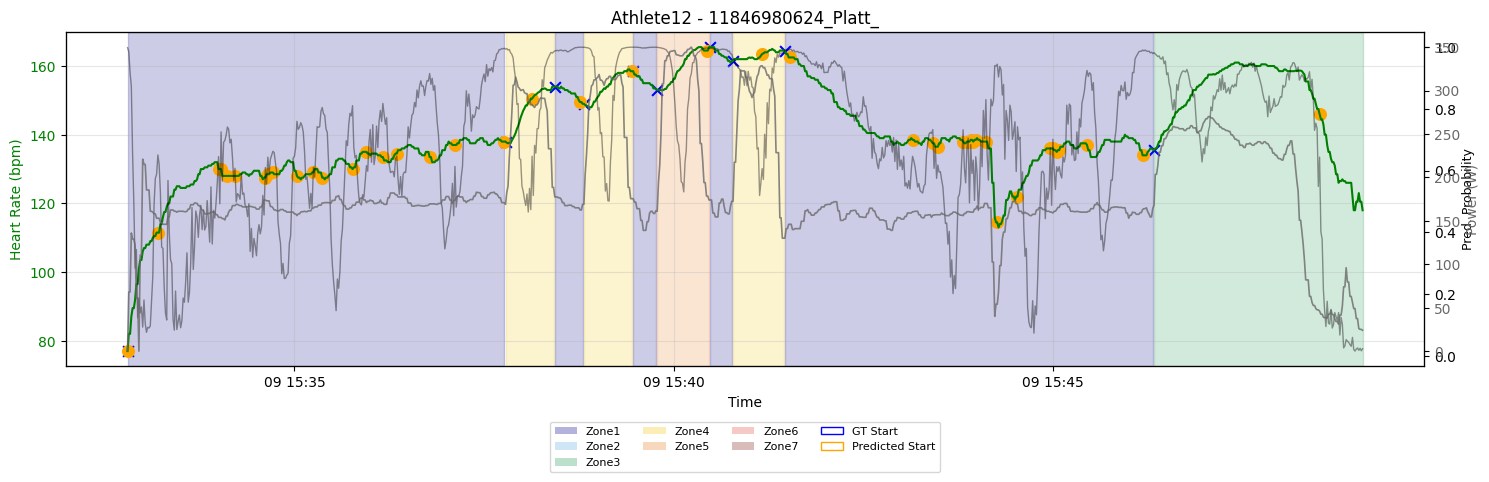

[Athlete12 | 12846436186_Synchronflug]  Intervals= 3  P=0.022  R=0.667  F1=0.043


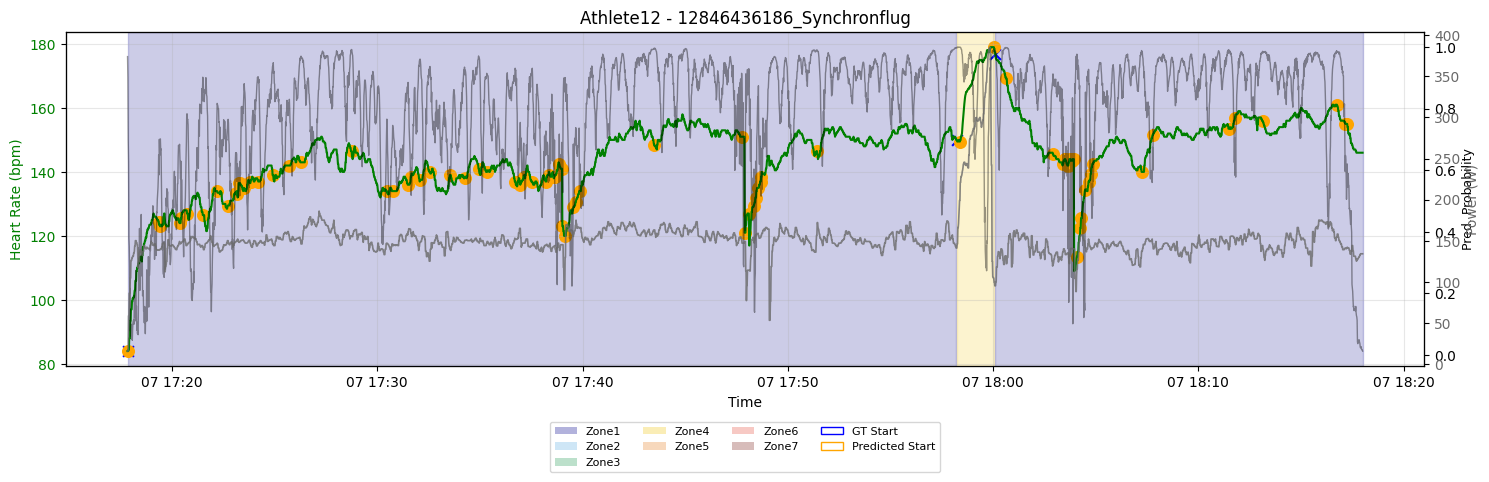

[Athlete12 | 11962243206_Wundmanagement]  Intervals=12  P=0.096  R=0.417  F1=0.156


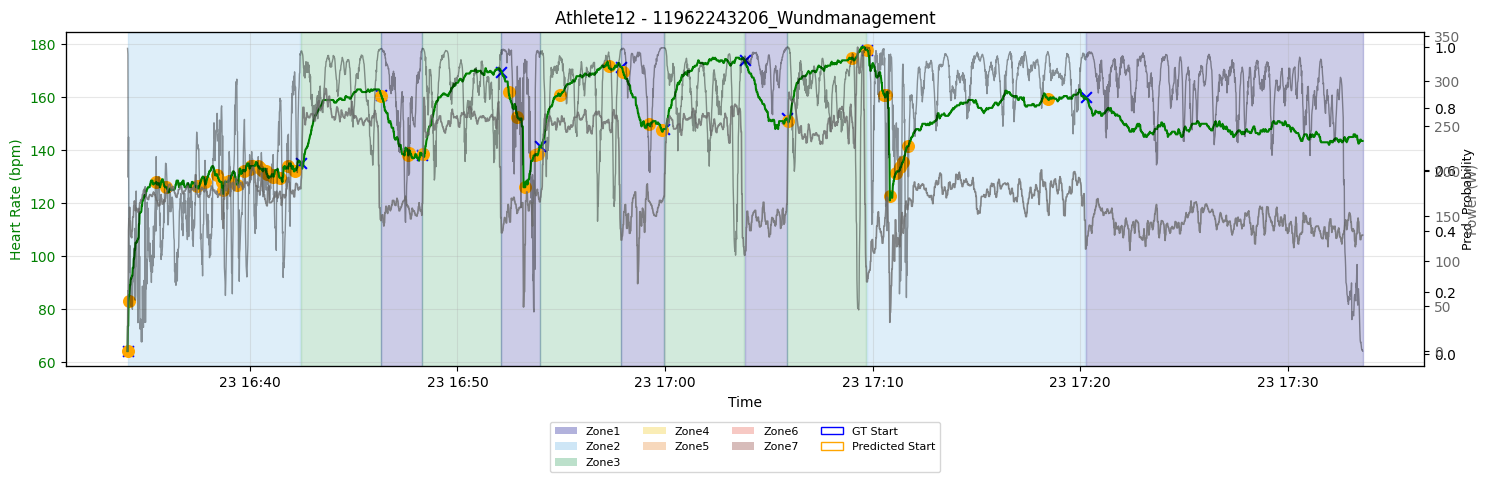

[Athlete12 | 13983533934_Technik__30er]  Intervals=11  P=0.143  R=0.364  F1=0.205


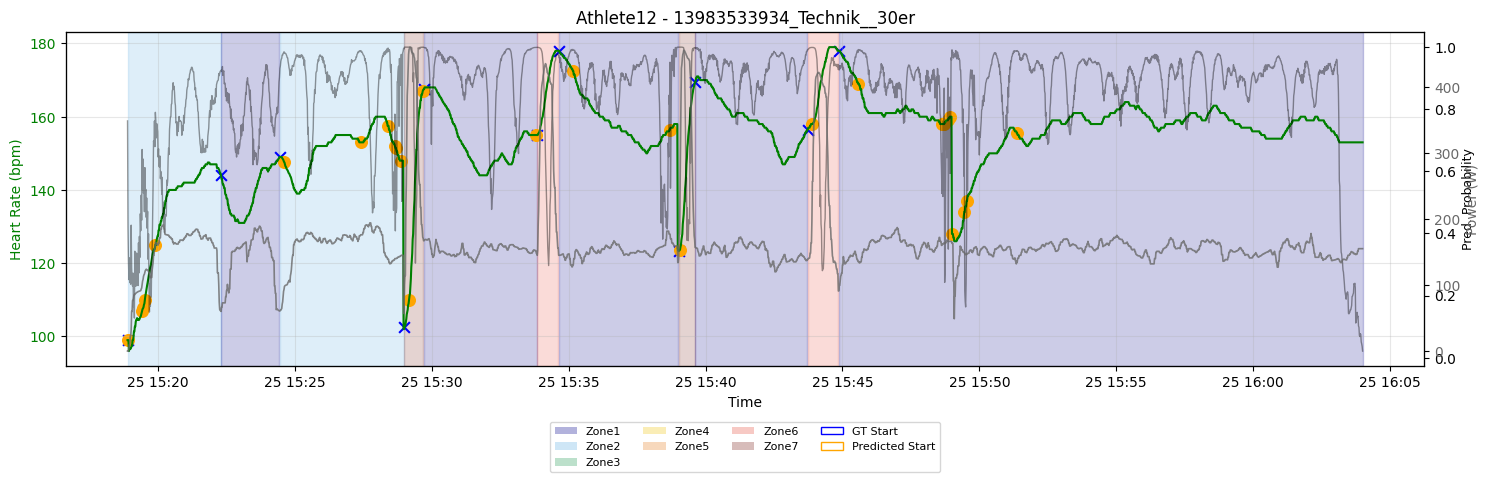

[Athlete12 | 13688068283_Luftpresser]  Intervals=11  P=0.091  R=0.364  F1=0.145


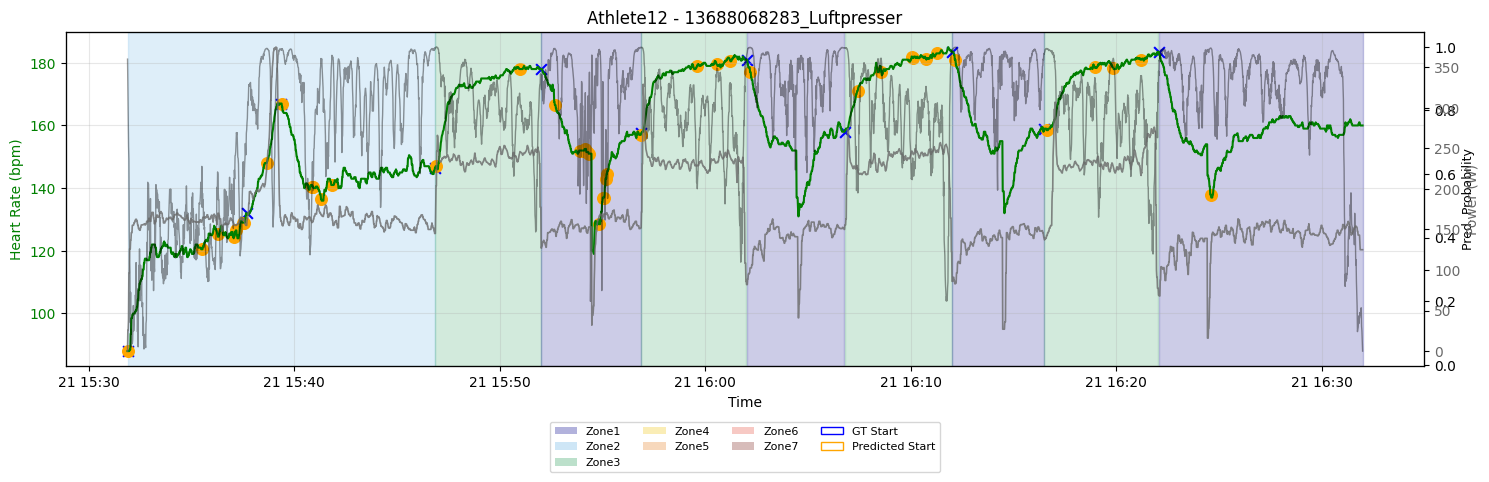

[Athlete12 | 14125110656_Vallah_isch_balla]  Intervals=11  P=0.102  R=0.455  F1=0.167


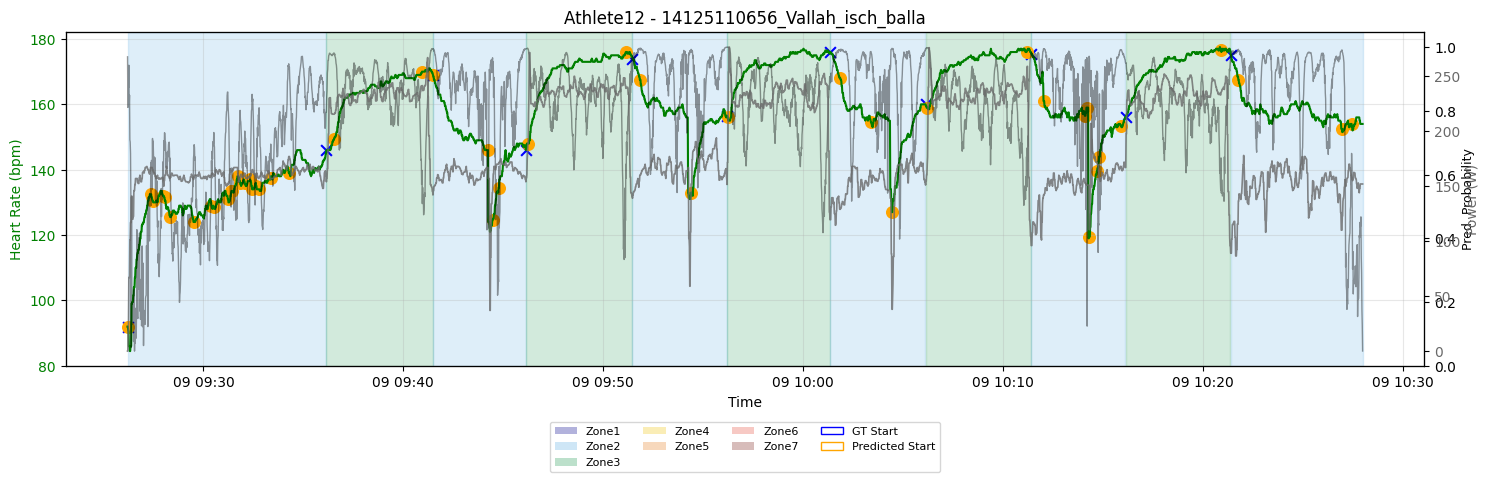

[Athlete12 | 11783093951_4x2000_sub8]  Intervals= 9  P=0.091  R=0.556  F1=0.156


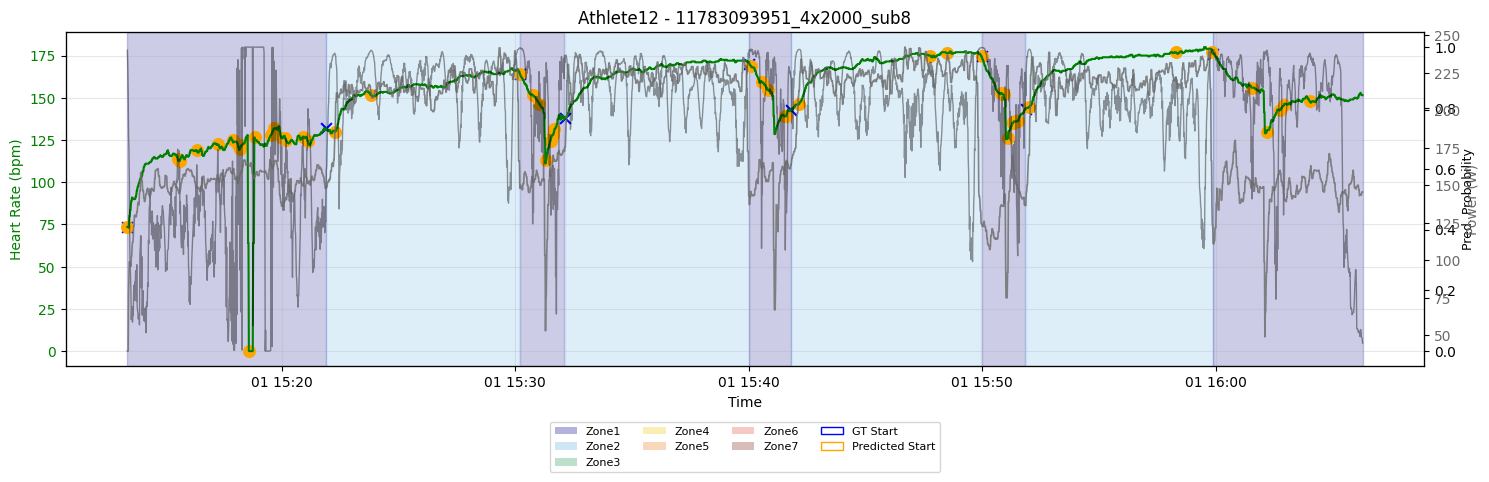

[Athlete12 | 12036692734_Exhausted]  Intervals= 9  P=0.111  R=0.444  F1=0.178


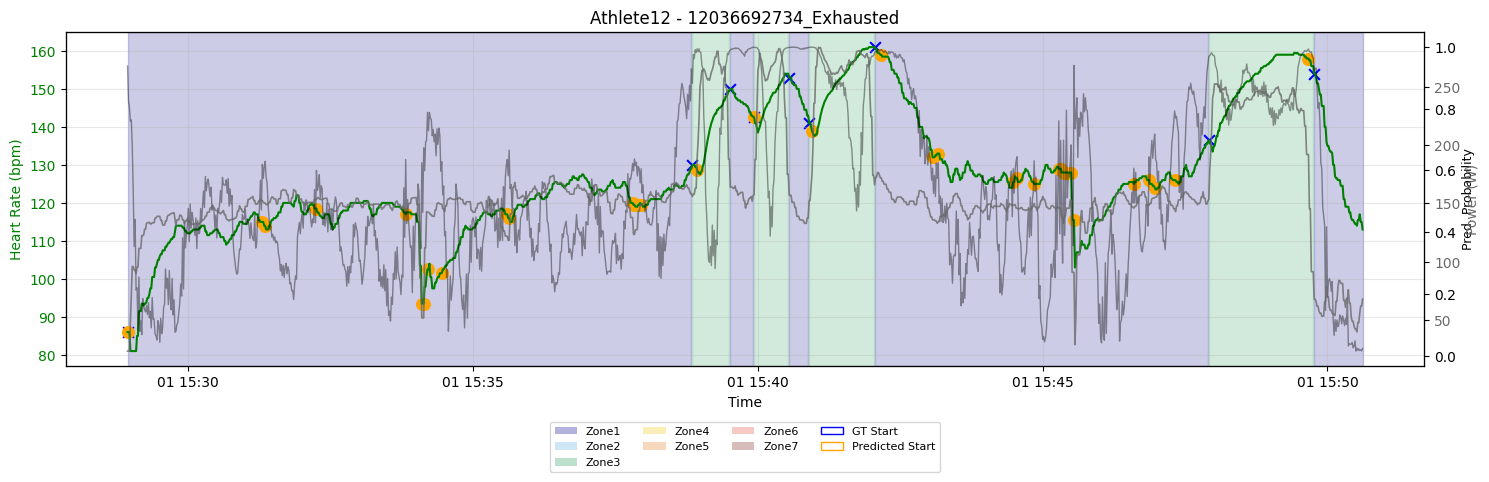

[Athlete12 | 13601462878_Zehnbauer]  Intervals= 9  P=0.231  R=0.667  F1=0.343


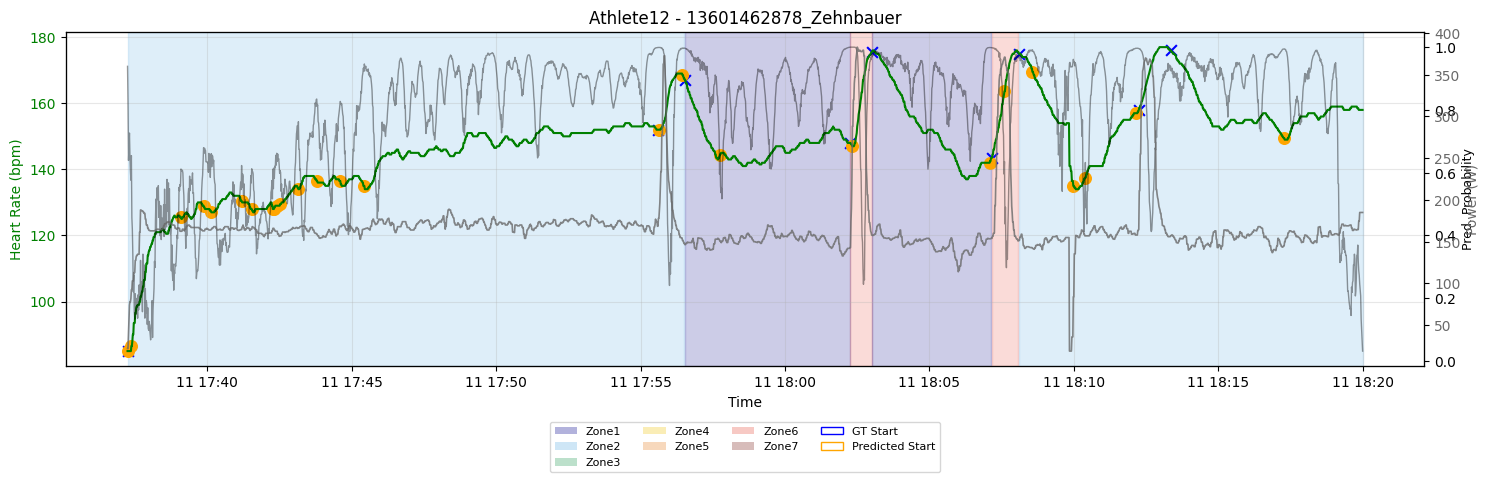

[Athlete2 | 13363782092_Zwift__Aerobic_Mixup_in_New_York]  Intervals=20  P=0.043  R=0.100  F1=0.060


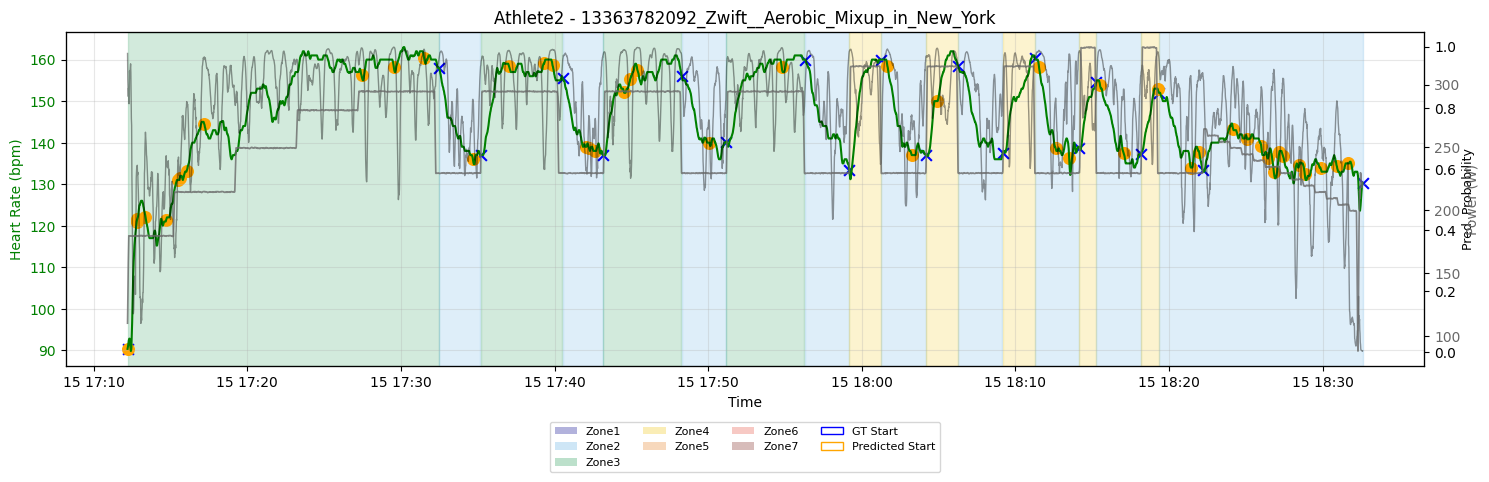

[Athlete2 | i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia]  Intervals=40  P=0.031  R=0.050  F1=0.038


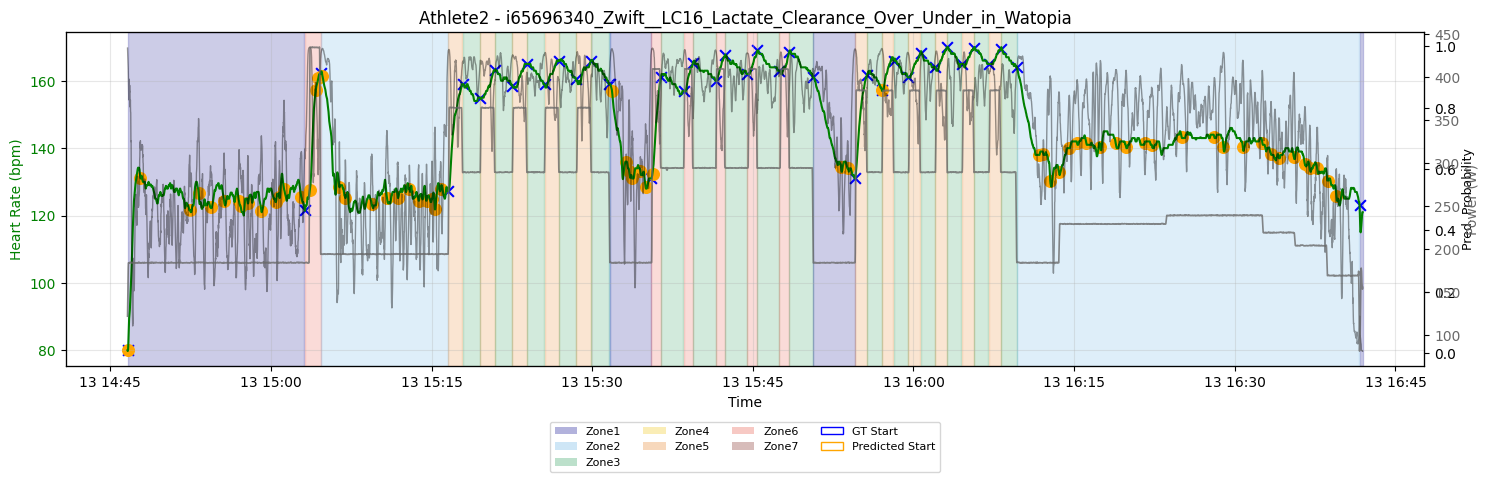

✅ Finished plotting all test sessions.


In [94]:
# Example: save all plots to "plots/test_sessions"
plot_all_test_sessions(
    model,
    test_session_dict,
    device,
    save_dir="plots/test_sessions",
    min_dist=3,   # seconds between peaks
    tol=5,        # evaluation tolerance
    show=True    # set True to view interactively
)
